## Problema - Organización y búsqueda de productos en una tienda




In [ ]:
# @title Ingrese datos
nombre_estudiante = "Sebastian Diaquive Castro" # @param {"type":"string"}
carnet = 1000107262 # @param {"type":"integer"}


## 1) Descripción del problema **[1 pts]**

Ejercicio: Dar cambio con monedas colombianas
Una tienda en Colombia necesita desarrollar un programa que calcule la menor cantidad de monedas necesarias para entregar un cambio determinado a un cliente.

La tienda dispone de las siguientes monedas:

monedas = [50, 100, 200, 500, 1000]
El usuario deberá ingresar el valor del cambio que necesita entregar.

## 2) Requerimientos **[2 pts]**

Lista requerimientos **funcionales** y **no funcionales**.

**FUNCIONALES**

RQF01: Solicitar, validar y en caso de ser necesario, aproximar la cantidad de la cual se desea dar "vueltas" o dar cambio.

RQF02: Por medio de Memoizacion se obtiene el menor numero de monedas que se deben dar para llegar a la cantidad requerida y la solucion.

RQF03: Imprimir los resultados.

RQF04: Preguntar y validar si el usuario desea usar el programa nuevamente.

**NO FUNCIONALES**

RQNF1: Optimizacion: El programa al usar la Memoizacion utiliza memoria para almacenar los datos de la recurrencia en lugar de tener que calcularse cada vez, el costo del programa es de  $T(n) = O(n)$

RQNF2: Claridad: Las instrucciones que se le dan al usuario son claras y al usar validacion, es mas flexible con el usuario

RQNF3: Modularidad: El codigo esta dividido por funciones, lo que nos facilita la modificacion o implementacion de las funciones a futuro

RQNF4: Lenguaje de programacion: El lenguaje de programacion empleado para la presentacion del programa es Python, ya que es mas didactico y comprensible para nosotros


## 3) Historias de usuario **[2 pts]**

**HISTORIAS DE USUARIO**

**HU01**
Ingresar la cantidad de la que se desea dar cambio (RQF01)

Salida incial: Ingrese la cantidad del cambio

Entrada: Numeros enteros mayores a 0 multiplos de 50

Caso de aceptacion: el usuario ingresa un numero valido

Caso de error: el usuario ingresa numeros no validos 

Salida de error: cantidad invalida digite nuevamente

**HU02**: Calcular por medio de la MEMOIZACION la cantidad de monedas minima para dar estas vueltas (RQF02)

Salida: Numero de monedas y la combinacion

**HU03**: Repetir o dejar de usar el programa (RQF04)

Entrada: SI O NO

Caso de error: El usuario pone una respuesta distinta a SI o NO

Caso de aceptacion: SI o NO

Salida de eeror: Respuesta no valida

Salida de exito: El programa se vuelve a realizar para ptrsp valores de  cambio 

## 4) Diagramas de flujo **[5 pts]**

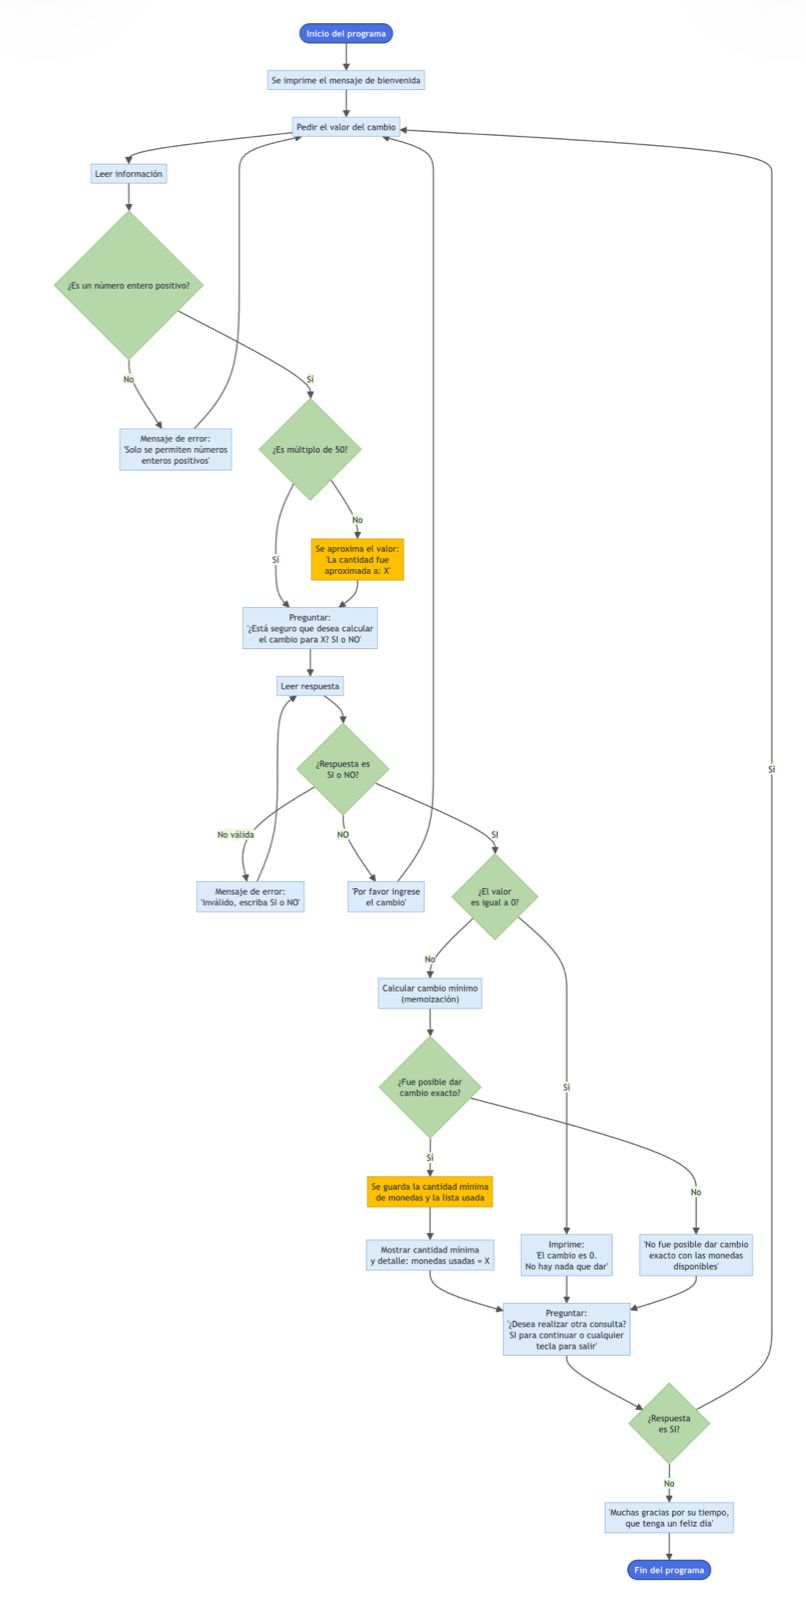

la lógica completa del programa para calcular el cambio en monedas: solicita y valida el valor del cambio (mayor a 1 y múltiplo de 50), pide confirmación al usuario, calcula y muestra la cantidad mínima de monedas junto con la solución, y pregunta si desea repetir el proceso o finalizar.
 


## 5) Diagramas de secuencia **[5 pts]**

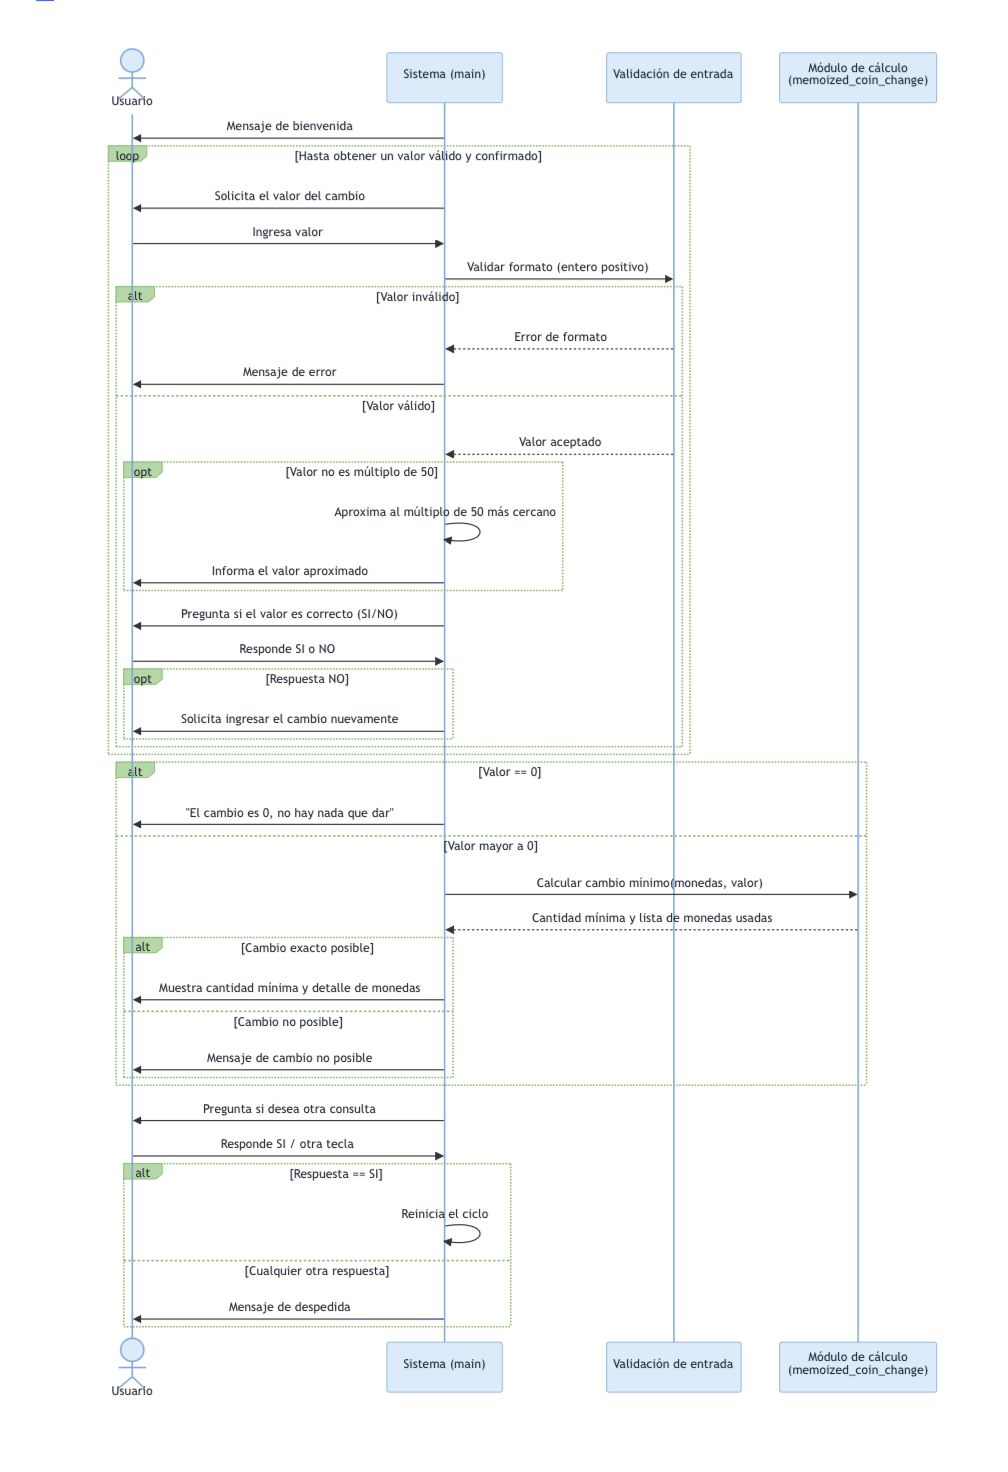

representa las acciones que el Usuario puede realizar en el sistema: ingresar el valor del cambio, confirmarlo y calcular el cambio en monedas, junto con las validaciones asociadas a cada acción.

## 6) Diagramas de casos de uso **[5 pts]**

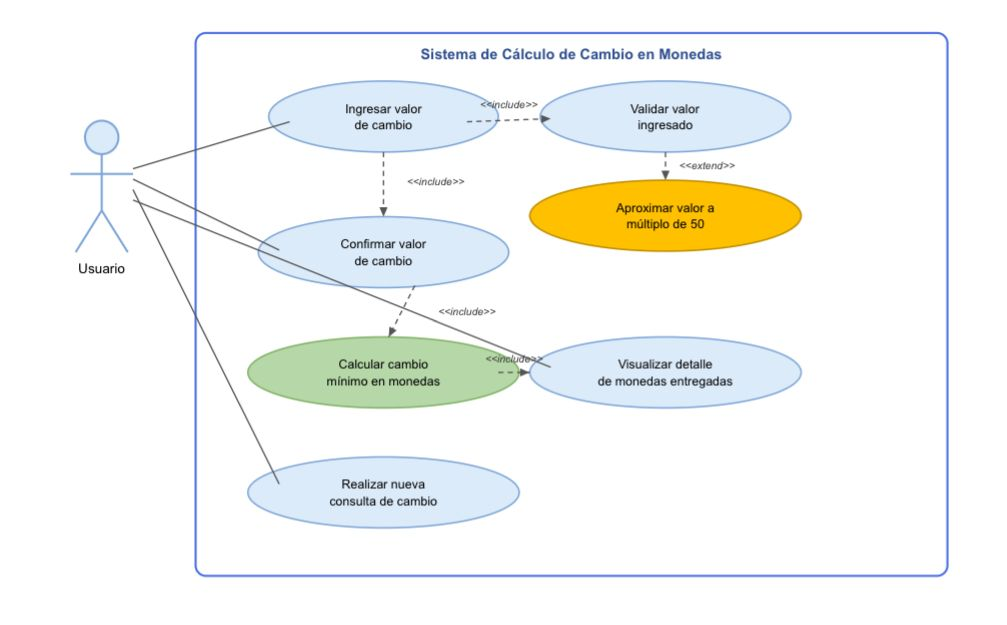

muestra el orden en que interactúan el Usuario, el Sistema y la Calculadora de Cambio, desde el ingreso y validación del valor, pasando por su confirmación, hasta el cálculo y la presentación de la cantidad mínima de monedas.

## 7) Análisis de complejidad **[5 pts]**

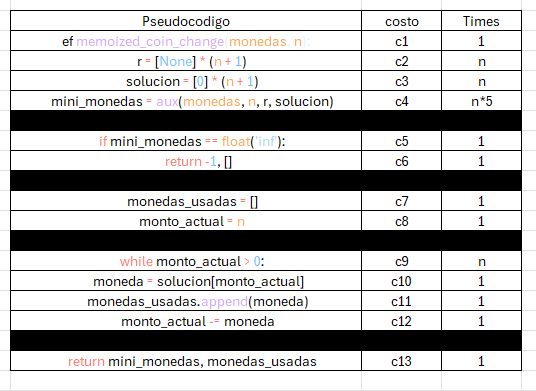

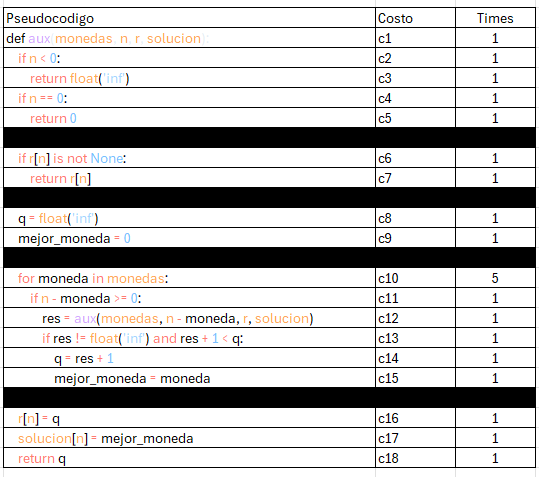

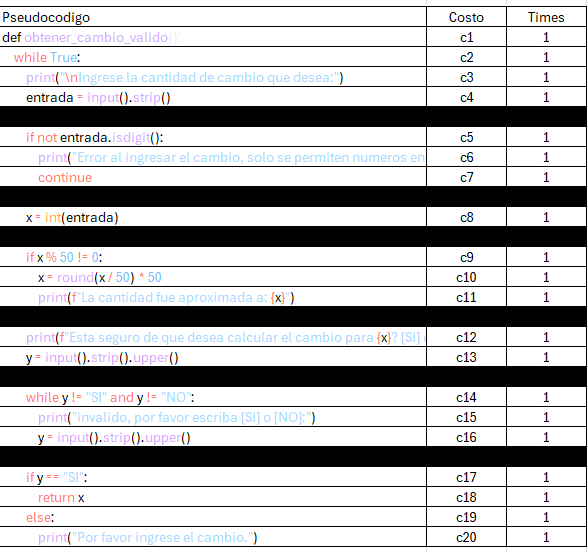

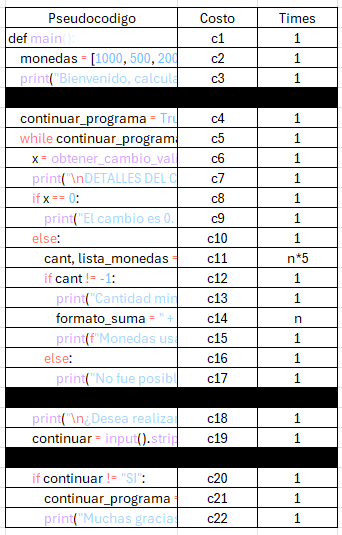


La memoizacion o programacion dinamica, generalmente tiene una complejidad de $ T(n) = O(n^2) $ , sin embargo, en este ejercicio, como en nuestro contexto se sabe que las monedas son solo 5, que son las de 50, 100, 200, 500 y 1000, una de nuestras $ n $, pasa a ser una constante que es el numero de monedas existentes en la economia de colombia, es decir, en este caso 5 monedas, es por esta razon que queda de la forma:

 $ T(n) = O(n)$


Sin embargo, si lo hablamos a terminos generales donde puede ser cualquier cantidad de monedas, la complejidad del codigo pasa a ser de:

$ T(n) = O(n^2) $



Como la complejidad se analiza con limites al infinito, la constante (5) se vuelve despreciable, por lo que la grafica de $ T(n) = O(n)$ es:

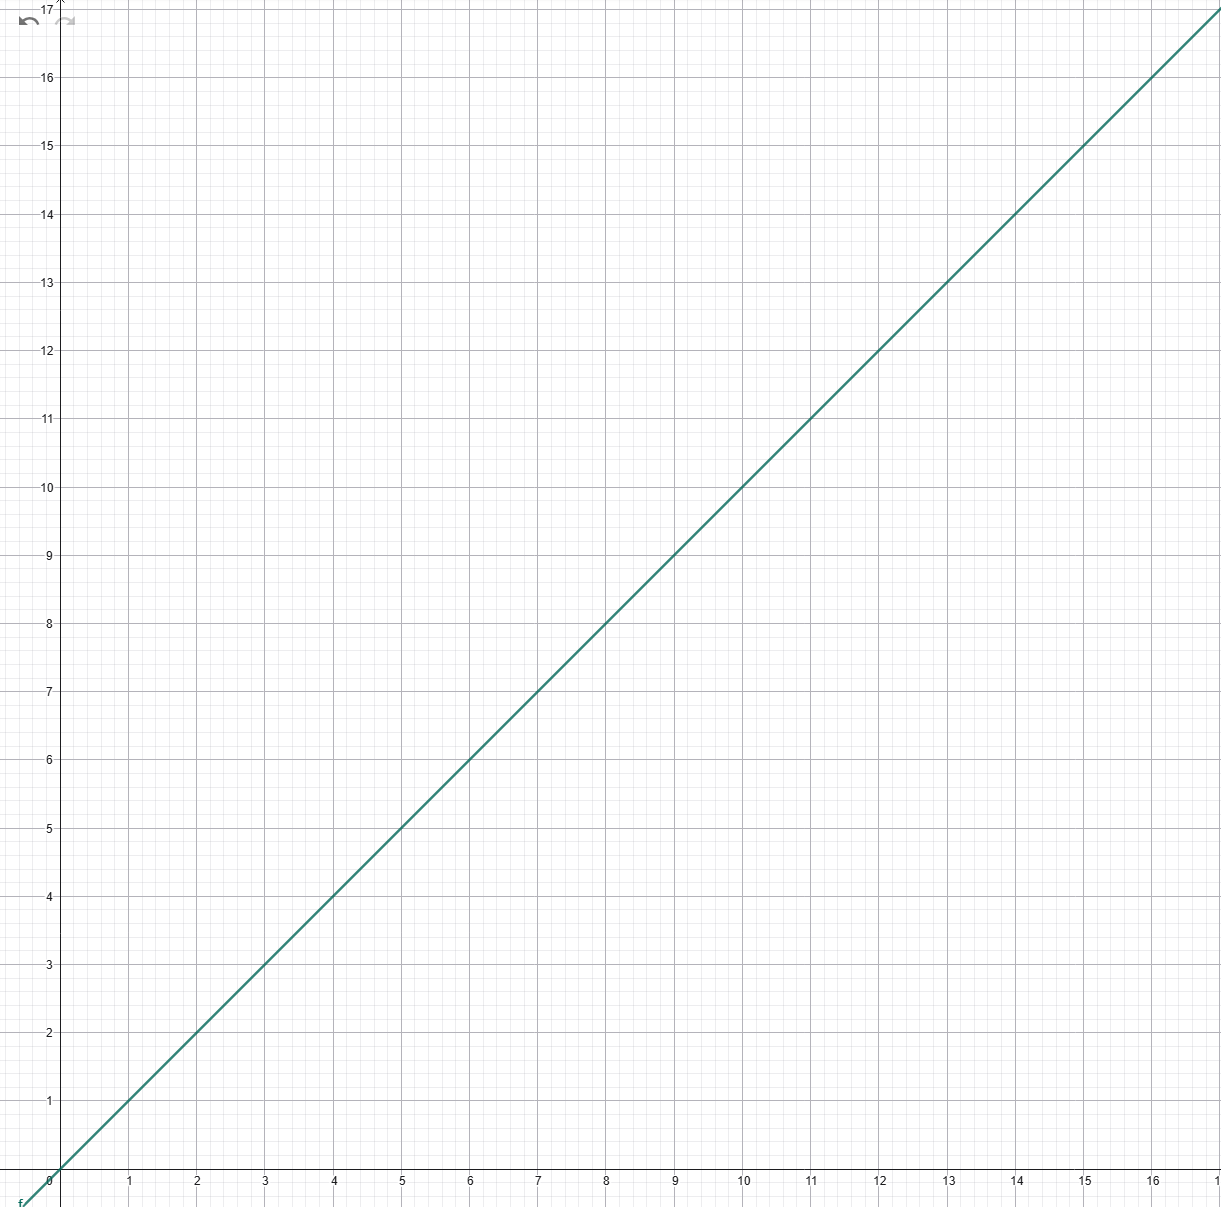


## 8) Código funcional **[10 pts]**
Incluye tu implementación completa.

No pegues código incompleto; debe ser ejecutable.


In [5]:
def memoized_coin_change(monedas, n):
    r = [None] * (n + 1)
    solucion = [0] * (n + 1)
    mini_monedas = aux(monedas, n, r, solucion)
    
    if mini_monedas == float('inf'):
        return -1, []

    monedas_usadas = []
    monto_actual = n
    
    while monto_actual > 0:
        moneda = solucion[monto_actual]
        monedas_usadas.append(moneda)
        monto_actual -= moneda
        
    return mini_monedas, monedas_usadas

def aux(monedas, n, r, solucion):
    if n < 0:
        return float('inf')
    if n == 0:
        return 0
        
    if r[n] is not None:
        return r[n]
    
    q = float('inf')
    mejor_moneda = 0
    
    for moneda in monedas:
        if n - moneda >= 0:
            res = aux(monedas, n - moneda, r, solucion)
            if res != float('inf') and res + 1 < q:
                q = res + 1
                mejor_moneda = moneda
                
    r[n] = q
    solucion[n] = mejor_moneda
    return q

def obtener_cambio_valido():
    while True:
        print("\nIngrese la cantidad de cambio que desea:")
        entrada = input().strip()
        
        if not entrada.isdigit():
            print("Error al ingresar el cambio, solo se permiten numeros enteros positivos. digite nuevamente por favor")
            continue
            
        x = int(entrada)

        if x % 50 != 0:
            x = round(x / 50) * 50
            print(f"La cantidad fue aproximada a: {x}")
            
        print(f"Esta seguro de que desea calcular el cambio para {x}? [SI] o [NO]:")
        y = input().strip().upper()
        
        while y != "SI" and y != "NO":
            print("invalido, por favor escriba [SI] o [NO]:")
            y = input().strip().upper()
            
        if y == "SI":
            return x
        else:
            print("Por favor ingrese el cambio.")

def main():
    monedas = [1000, 500, 200, 100, 50]
    print("Bienvenido, calcularemos el cambio en monedas para sus clientes.")
    
    continuar_programa = True
    while continuar_programa:
        x = obtener_cambio_valido()
        print("\nDETALLES DEL CAMBIO")
        if x == 0:
            print("El cambio es 0. No hay nada que dar")
        else:
            cant, lista_monedas = memoized_coin_change(monedas, x)
            if cant != -1:
                print("Cantidad minima de monedas usadas:", cant)
                formato_suma = " + ".join(map(str, lista_monedas))
                print(f"Monedas usadas para el cambio: {formato_suma} = {x}")
            else:
                print("No fue posible dar cambio exacto con las monedas disponibles.")
            
        print("\n¿Desea realizar otra consulta? [SI] para continuar o cualquier otra tecla para salir:")
        continuar = input().strip().upper()
        
        if continuar != "SI":
            continuar_programa = False
            print("Muchas gracias por su tiempo, que tenga un feliz día.")

main()

Bienvenido, calcularemos el cambio en monedas para sus clientes.

Ingrese la cantidad de cambio que desea:
Esta seguro de que desea calcular el cambio para 2550? [SI] o [NO]:

DETALLES DEL CAMBIO
Cantidad minima de monedas usadas: 4
Monedas usadas para el cambio: 1000 + 1000 + 500 + 50 = 2550

¿Desea realizar otra consulta? [SI] para continuar o cualquier otra tecla para salir:
Muchas gracias por su tiempo, que tenga un feliz día.


## 9) pruebas **[15 pts]**

In [4]:
def test(input, expected_output):
    monedas = [1000, 500, 200, 100, 50]
    got_output, _ = memoized_coin_change(monedas, input)
    assert got_output == expected_output, f"se obtuvo {got_output}, pero se esperaba {expected_output}"
    print(f"Paso caso de prueba {input} -> {expected_output}")

## Pruebas de enunciado

Casos de prueba proporcionados por el enunciado:

Ingrese el valor del cambio: 1850 = **ENTRADA**
El programa debe determinar cuál es la menor cantidad de monedas necesaria para completar exactamente ese valor.

Una posible solución sería:

1000 + 500 + 200 + 100 + 50 = 1850
Por lo tanto:

Cantidad mínima de monedas: 5 = **SALIDA ESPERADA**

Salida obtenida = 5



In [3]:
def memoized_coin_change(monedas, n):
    r = [None] * (n + 1)
    solucion = [0] * (n + 1)
    mini_monedas = aux(monedas, n, r, solucion)
    
    if mini_monedas == float('inf'):
        return -1, []

    monedas_usadas = []
    monto_actual = n
    
    while monto_actual > 0:
        moneda = solucion[monto_actual]
        monedas_usadas.append(moneda)
        monto_actual -= moneda
        
    return mini_monedas, monedas_usadas

def aux(monedas, n, r, solucion):
    if n < 0:
        return float('inf')
    if n == 0:
        return 0
        
    if r[n] is not None:
        return r[n]
    
    q = float('inf')
    mejor_moneda = 0
    
    for moneda in monedas:
        if n - moneda >= 0:
            res = aux(monedas, n - moneda, r, solucion)
            if res != float('inf') and res + 1 < q:
                q = res + 1
                mejor_moneda = moneda
                
    r[n] = q
    solucion[n] = mejor_moneda
    return q

def obtener_cambio_valido():
    while True:
        print("\nIngrese la cantidad de cambio que desea:")
        entrada = input().strip()
        
        if not entrada.isdigit():
            print("Error al ingresar el cambio, solo se permiten numeros enteros positivos. digite nuevamente por favor")
            continue
            
        x = int(entrada)

        if x % 50 != 0:
            x = round(x / 50) * 50
            print(f"La cantidad fue aproximada a: {x}")
            
        print(f"Esta seguro de que desea calcular el cambio para {x}? [SI] o [NO]:")
        y = input().strip().upper()
        
        while y != "SI" and y != "NO":
            print("invalido, por favor escriba [SI] o [NO]:")
            y = input().strip().upper()
            
        if y == "SI":
            return x
        else:
            print("Por favor ingrese el cambio.")

def main():
    monedas = [1000, 500, 200, 100, 50]
    print("Bienvenido, calcularemos el cambio en monedas para sus clientes.")
    
    continuar_programa = True
    while continuar_programa:
        x = obtener_cambio_valido()
        print("\nDETALLES DEL CAMBIO")
        if x == 0:
            print("El cambio es 0. No hay nada que dar")
        else:
            cant, lista_monedas = memoized_coin_change(monedas, x)
            if cant != -1:
                print("Cantidad minima de monedas usadas:", cant)
                formato_suma = " + ".join(map(str, lista_monedas))
                print(f"Monedas usadas para el cambio: {formato_suma} = {x}")
            else:
                print("No fue posible dar cambio exacto con las monedas disponibles.")
            
        print("\n¿Desea realizar otra consulta? [SI] para continuar o cualquier otra tecla para salir:")
        continuar = input().strip().upper()
        
        if continuar != "SI":
            continuar_programa = False
            print("Muchas gracias por su tiempo, que tenga un feliz día.")

def test(input, expected_output):
    monedas = [1000, 500, 200, 100, 50]
    got_output, _ = memoized_coin_change(monedas, input)
    assert got_output == expected_output, f"se obtuvo {got_output}, pero se esperaba {expected_output}"
    print(f"Paso caso de prueba {input} -> {expected_output}")


test(1850, 5)   

Paso caso de prueba 1850 -> 5


## Pruebas propias

**Prueba 1**

Entrada = 1000

Salida esperada = 1

Salida obtenida = 1

**Prueba 2**

Entrada = 350

Salida esperada = 3

Salida obtenida = 3

In [2]:
def memoized_coin_change(monedas, n):
    r = [None] * (n + 1)
    solucion = [0] * (n + 1)
    mini_monedas = aux(monedas, n, r, solucion)
    
    if mini_monedas == float('inf'):
        return -1, []

    monedas_usadas = []
    monto_actual = n
    
    while monto_actual > 0:
        moneda = solucion[monto_actual]
        monedas_usadas.append(moneda)
        monto_actual -= moneda
        
    return mini_monedas, monedas_usadas

def aux(monedas, n, r, solucion):
    if n < 0:
        return float('inf')
    if n == 0:
        return 0
        
    if r[n] is not None:
        return r[n]
    
    q = float('inf')
    mejor_moneda = 0
    
    for moneda in monedas:
        if n - moneda >= 0:
            res = aux(monedas, n - moneda, r, solucion)
            if res != float('inf') and res + 1 < q:
                q = res + 1
                mejor_moneda = moneda
                
    r[n] = q
    solucion[n] = mejor_moneda
    return q

def obtener_cambio_valido():
    while True:
        print("\nIngrese la cantidad de cambio que desea:")
        entrada = input().strip()
        
        if not entrada.isdigit():
            print("Error al ingresar el cambio, solo se permiten numeros enteros positivos. digite nuevamente por favor")
            continue
            
        x = int(entrada)

        if x % 50 != 0:
            x = round(x / 50) * 50
            print(f"La cantidad fue aproximada a: {x}")
            
        print(f"Esta seguro de que desea calcular el cambio para {x}? [SI] o [NO]:")
        y = input().strip().upper()
        
        while y != "SI" and y != "NO":
            print("invalido, por favor escriba [SI] o [NO]:")
            y = input().strip().upper()
            
        if y == "SI":
            return x
        else:
            print("Por favor ingrese el cambio.")

def main():
    monedas = [1000, 500, 200, 100, 50]
    print("Bienvenido, calcularemos el cambio en monedas para sus clientes.")
    
    continuar_programa = True
    while continuar_programa:
        x = obtener_cambio_valido()
        print("\nDETALLES DEL CAMBIO")
        if x == 0:
            print("El cambio es 0. No hay nada que dar")
        else:
            cant, lista_monedas = memoized_coin_change(monedas, x)
            if cant != -1:
                print("Cantidad minima de monedas usadas:", cant)
                formato_suma = " + ".join(map(str, lista_monedas))
                print(f"Monedas usadas para el cambio: {formato_suma} = {x}")
            else:
                print("No fue posible dar cambio exacto con las monedas disponibles.")
            
        print("\n¿Desea realizar otra consulta? [SI] para continuar o cualquier otra tecla para salir:")
        continuar = input().strip().upper()
        
        if continuar != "SI":
            continuar_programa = False
            print("Muchas gracias por su tiempo, que tenga un feliz día.")

def test(input, expected_output):
    monedas = [1000, 500, 200, 100, 50]
    got_output, _ = memoized_coin_change(monedas, input)
    assert got_output == expected_output, f"se obtuvo {got_output}, pero se esperaba {expected_output}"
    print(f"Paso caso de prueba {input} -> {expected_output}")


test(1000, 1)
test(350 , 3)   

Paso caso de prueba 1000 -> 1
Paso caso de prueba 350 -> 3


## Pruebas de Desempeño
Qué va aquí?

Medición empírica del tiempo de ejecución.

Gráfica de comportamiento.

Relación entre la gráfica obtenida y el análisis de complejidad teórico.

#### Código base para benchmarking

Generando datos ...........................................


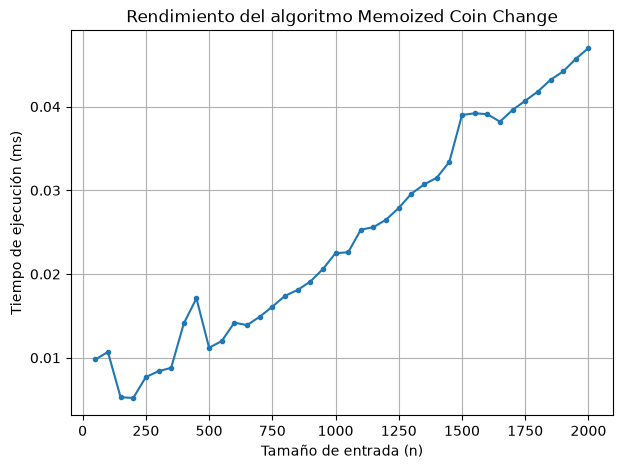

In [1]:
def memoized_coin_change(monedas, n):
    r = [None] * (n + 1)
    solucion = [0] * (n + 1)
    mini_monedas = aux(monedas, n, r, solucion)
    
    if mini_monedas == float('inf'):
        return -1, []

    monedas_usadas = []
    monto_actual = n
    
    while monto_actual > 0:
        moneda = solucion[monto_actual]
        monedas_usadas.append(moneda)
        monto_actual -= moneda
        
    return mini_monedas, monedas_usadas

def aux(monedas, n, r, solucion):
    if n < 0:
        return float('inf')
    if n == 0:
        return 0
        
    if r[n] is not None:
        return r[n]
    
    q = float('inf')
    mejor_moneda = 0
    
    for moneda in monedas:
        if n - moneda >= 0:
            res = aux(monedas, n - moneda, r, solucion)
            if res != float('inf') and res + 1 < q:
                q = res + 1
                mejor_moneda = moneda
                
    r[n] = q
    solucion[n] = mejor_moneda
    return q

def obtener_cambio_valido():
    while True:
        print("\nIngrese la cantidad de cambio que desea:")
        entrada = input().strip()
        
        if not entrada.isdigit():
            print("Error al ingresar el cambio, solo se permiten numeros enteros positivos. digite nuevamente por favor")
            continue
            
        x = int(entrada)

        if x % 50 != 0:
            x = round(x / 50) * 50
            print(f"La cantidad fue aproximada a: {x}")
            
        print(f"Esta seguro de que desea calcular el cambio para {x}? [SI] o [NO]:")
        y = input().strip().upper()
        
        while y != "SI" and y != "NO":
            print("invalido, por favor escriba [SI] o [NO]:")
            y = input().strip().upper()
            
        if y == "SI":
            return x
        else:
            print("Por favor ingrese el cambio.")

def main():
    monedas = [1000, 500, 200, 100, 50]
    print("Bienvenido, calcularemos el cambio en monedas para sus clientes.")
    
    continuar_programa = True
    while continuar_programa:
        x = obtener_cambio_valido()
        print("\nDETALLES DEL CAMBIO")
        if x == 0:
            print("El cambio es 0. No hay nada que dar")
        else:
            cant, lista_monedas = memoized_coin_change(monedas, x)
            if cant != -1:
                print("Cantidad minima de monedas usadas:", cant)
                formato_suma = " + ".join(map(str, lista_monedas))
                print(f"Monedas usadas para el cambio: {formato_suma} = {x}")
            else:
                print("No fue posible dar cambio exacto con las monedas disponibles.")
            
        print("\n¿Desea realizar otra consulta? [SI] para continuar o cualquier otra tecla para salir:")
        continuar = input().strip().upper()
        
        if continuar != "SI":
            continuar_programa = False
            print("Muchas gracias por su tiempo, que tenga un feliz día.")

def test(input, expected_output):
    monedas = [1000, 500, 200, 100, 50]
    got_output, _ = memoized_coin_change(monedas, input)
    assert got_output == expected_output, f"se obtuvo {got_output}, pero se esperaba {expected_output}"
    print(f"Paso caso de prueba {input} -> {expected_output}")


def bench(n: int, step: int = 50) -> list[tuple[int, float]]:
    print("Generando datos ...", end='')
    import time
    results: list[tuple[int, float]] = []
    monedas = [1000, 500, 200, 100, 50]
    
    for size in range(50, n + 1, step):
        ti = time.perf_counter()
        memoized_coin_change(monedas, size)
        tf = time.perf_counter()
        
        delta = (tf - ti) * 1000
        print(".", end="")
        results.append((size, delta))
    print()
    return results

def dibujar(x, y, dimensiones=(7, 5)):
    assert len(x) == len(y)
    import matplotlib.pyplot as plt
    plt.figure(figsize=dimensiones)
    plt.plot(x, y, marker='o', markersize=3)
    plt.title("Rendimiento del algoritmo Memoized Coin Change")
    plt.xlabel("Tamaño de entrada (n)")
    plt.ylabel("Tiempo de ejecución (ms)")
    plt.grid(True)
    plt.show()

tiempos = bench(2000, step=50)
x = [size for size, timing in tiempos]
y = [timing for size, timing in tiempos]
dibujar(x, y)